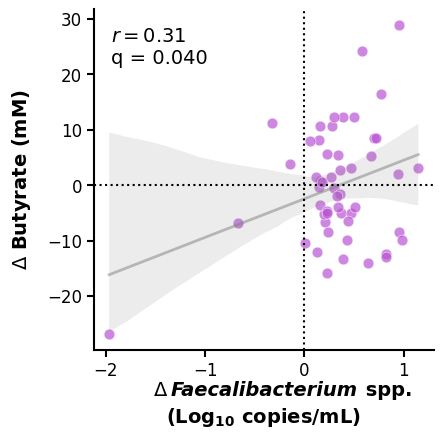

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.stats.multitest as multitest
import warnings
import os

warnings.filterwarnings('ignore')

# =============================================================================
# 1. Settings (Publication Quality)
# =============================================================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
DPI_SETTING = 600

def clean_and_convert(vals):
    s_vals = pd.Series(vals).astype(str).str.strip()
    s_vals = s_vals.replace(['Undetermined', '-', 'nan', 'NaN', '#VALUE!', ''], '0')
    s_vals = s_vals.str.replace(r'\.E\+', 'E+', regex=True)
    s_vals = s_vals.str.replace(r'\.E\-', 'E-', regex=True)
    return pd.to_numeric(s_vals, errors='coerce').fillna(0)

# =============================================================================
# 2. Data Loading, Correlation, and FDR Correction
# =============================================================================
df_but = pd.read_csv('Butyrate(mM).csv')
donor_cols_but = [c for c in df_but.columns if c.startswith('HS-')]
but_ctrl = clean_and_convert(df_but[df_but['KULFFI'].str.strip() == 'Control'][donor_cols_but].iloc[0])
but_inulin = clean_and_convert(df_but[df_but['KULFFI'].str.strip() == 'Inulin'][donor_cols_but].iloc[0])
delta_but = but_inulin - but_ctrl

taxa_files = {
    'Bifidobacterium': 'Bifidobacterium(qPCR).csv',
    'Blautia': 'Blautia(qPCR).csv',
    'Faecalibacterium': 'Faecalibacterium(qPCR).csv',
    'Butyricicoccus': 'Butyricicoccus(qPCR).csv',
    'Anaerostipes caccae': 'A.caccae.csv'
}

r_vals = []
p_vals = []
valid_taxa = []
delta_fcal_saved = None

for taxon, filename in taxa_files.items():
    if not os.path.exists(filename): continue
    try:
        df = pd.read_csv(filename)
    except UnicodeDecodeError:
        df = pd.read_csv(filename, encoding='shift_jis')

    donor_cols = [c for c in df.columns if c.startswith('HS-')]
    ctrl_vals = clean_and_convert(df[df['KULFFI'].str.strip() == 'Control'][donor_cols].iloc[0])
    inulin_vals = clean_and_convert(df[df['KULFFI'].str.strip() == 'Inulin'][donor_cols].iloc[0])

    delta_taxa = np.log10(inulin_vals + 1) - np.log10(ctrl_vals + 1)

    if taxon == 'Faecalibacterium':
        delta_fcal_saved = delta_taxa

    r, p = stats.pearsonr(delta_taxa, delta_but)
    r_vals.append(r)
    p_vals.append(p)
    valid_taxa.append(taxon)

# FDR correction across all 5 taxa
_, q_vals, _, _ = multitest.multipletests(p_vals, alpha=0.05, method='fdr_bh')
fcal_idx = valid_taxa.index('Faecalibacterium')
r_fcal = r_vals[fcal_idx]
q_fcal = q_vals[fcal_idx]

df_plot = pd.DataFrame({
    'Delta_Faecali': delta_fcal_saved,
    'Delta_Butyrate': delta_but
})

# =============================================================================
# 3. Figure Generation
# =============================================================================
fig, ax = plt.subplots(figsize=(5, 5))
inulin_color = '#BA55D3'

# Scatter plot and regression line
sns.regplot(x='Delta_Faecali', y='Delta_Butyrate', data=df_plot, ax=ax, color=inulin_color,
            scatter_kws={'s': 60, 'alpha': 0.7, 'edgecolors': 'white', 'linewidths': 0.5},
            line_kws={'linewidth': 2, 'color': 'gray', 'alpha': 0.5, 'linestyle': '-'})

ax.axhline(0, color='black', linestyle=':', linewidth=1.5)
ax.axvline(0, color='black', linestyle=':', linewidth=1.5)

ax.set_xlabel('')
ax.set_ylabel(r'$\Delta$ Butyrate (mM)', fontsize=14, fontweight='bold', labelpad=10)

ax.tick_params(axis='both', labelsize=12, width=1.5, length=5)

for spine in ['left', 'bottom']: ax.spines[spine].set_linewidth(1.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_box_aspect(1)

# Custom Centered X-axis Label (Avoiding PDF MathText limitations)
x_center = 0.5
y_base = -0.12
fcal_half_width = 0.28 # Fine-tuned anchor spread for longer 'Faecalibacterium' string

ax.text(x_center, y_base, 'Faecalibacterium', transform=ax.transAxes,
        fontsize=14, fontweight='bold', fontstyle='italic', ha='center', va='center')

ax.text(x_center - fcal_half_width, y_base, r'$\Delta$ ', transform=ax.transAxes,
        fontsize=14, fontweight='bold', ha='right', va='center')

ax.text(x_center + fcal_half_width, y_base, ' spp.', transform=ax.transAxes,
        fontsize=14, fontweight='bold', ha='left', va='center')

ax.text(x_center, y_base - 0.08, r'(Log$_{\mathbf{10}}$ copies/mL)', transform=ax.transAxes,
        fontsize=14, fontweight='bold', ha='center', va='center')

# Stats Box
q_text = "q < 0.001" if q_fcal < 0.001 else f"q = {q_fcal:.3f}"
stats_text = f"$r = {r_fcal:.2f}$\n{q_text}"

ax.text(0.05, 0.95, stats_text, transform=ax.transAxes,
        fontsize=14, fontweight='normal', va='top', ha='left', color='black',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=1.0, edgecolor='none'))

plt.subplots_adjust(bottom=0.2)

# =============================================================================
# 4. Output
# =============================================================================
plt.savefig('Figure_4h.pdf', dpi=DPI_SETTING, bbox_inches='tight', transparent=True)